In [1]:
import pandas as pd
from pathlib import Path

repo = "https://raw.githubusercontent.com/Joshua-Pillai/AD/main/ClinVar"
genes = ["APOE", "APP", "MAPT", "PSEN1", "PSEN2", "TREM2"]
out = Path("/content/ad_csv"); out.mkdir(parents=True, exist_ok=True)

total = 0
for g in genes:
    df = pd.read_csv(f"{repo}/{g}_ClinVar.txt", sep="\t", low_memory=False)
    df.to_csv(out / f"{g}.csv", index=False)
    print(f"{g}: {len(df)} variants")
    total += len(df)

print(f"\nTotal: {total:,} variants across {len(genes)} genes")

df = pd.read_csv(out / "APOE.csv", low_memory=False)
print(f"APOE.csv: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.columns.tolist())

APOE: 300 variants
APP: 715 variants
MAPT: 672 variants
PSEN1: 640 variants
PSEN2: 407 variants
TREM2: 202 variants

Total: 2,936 variants across 6 genes
APOE.csv: 300 rows, 25 columns
['Name', 'Gene(s)', 'Protein change', 'Condition(s)', 'Accession', 'GRCh37Chromosome', 'GRCh37Location', 'GRCh38Chromosome', 'GRCh38Location', 'VariationID', 'AlleleID(s)', 'dbSNP ID', 'Canonical SPDI', 'Variant type', 'Molecular consequence', 'Germline classification', 'Germline date last evaluated', 'Germline review status', 'Somatic clinical impact', 'Somatic clinical impact date last evaluated', 'Somatic clinical impact review status', 'Oncogenicity classification', 'Oncogenicity date last evaluated', 'Oncogenicity review status', 'Unnamed: 24']


In [2]:
import pandas as pd
from pathlib import Path

csv_dir = Path("/content/ad_csv")
genes = ["APOE", "APP", "MAPT", "PSEN1", "PSEN2", "TREM2"]

frames = [pd.read_csv(csv_dir / f"{g}.csv", low_memory=False).assign(source=g) for g in genes]
ad = pd.concat(frames, ignore_index=True)

print(f"Total rows:     {len(ad):>7,}")
print(f"Unique IDs:     {ad['VariationID'].nunique():>7,}")
print(f"Duplicate rows: {len(ad) - ad['VariationID'].nunique():>7,}")

dup_vids = ad["VariationID"].value_counts().loc[lambda x: x > 1]
dup_rows = ad[ad["VariationID"].isin(dup_vids.index)]
overlap = dup_rows.groupby("VariationID")["source"].apply(lambda s: " + ".join(sorted(s.unique())))

print(f"\nVariants in >1 file: {len(dup_vids)}")
print("\nOverlap patterns:")
print(overlap.value_counts().to_string())

cnv = {"copy number gain","copy number loss","Deletion","Duplication"}
unique_dups = dup_rows.drop_duplicates("VariationID")
non_cnv = unique_dups[~unique_dups["Variant type"].isin(cnv)]
if len(non_cnv) > 0:
    print(f"\nNon-CNV duplicates ({len(non_cnv)}):")
    print(non_cnv[["VariationID","Name","Variant type","Germline classification"]].to_string(index=False))

dup_rows.sort_values(["VariationID","source"]).to_csv("/content/ad_duplicate_report.csv", index=False)

Total rows:       2,936
Unique IDs:       2,936
Duplicate rows:       0

Variants in >1 file: 0

Overlap patterns:
Series([], )


In [4]:
print(ad["Germline classification"].value_counts(dropna=False).to_string())

Germline classification
Uncertain significance                                              1123
Likely benign                                                        699
Pathogenic                                                           337
Benign                                                               227
Conflicting classifications of pathogenicity                         162
Likely pathogenic                                                     95
Benign/Likely benign                                                  88
not provided                                                          84
NaN                                                                   73
Pathogenic/Likely pathogenic                                          31
no classification for the single variant                               6
drug response                                                          4
risk factor                                                            3
association                

In [5]:
print(f"Total variants: {len(ad):,}\n")

print("Variant type distribution:")
vt = ad["Variant type"].value_counts(dropna=False)
print(pd.DataFrame({"count": vt, "pct": (vt/len(ad)*100).round(2)}).to_string())

print("\nMolecular consequence (top 15):")
mc = ad["Molecular consequence"].value_counts(dropna=False).head(15)
print(pd.DataFrame({"count": mc, "pct": (mc/len(ad)*100).round(2)}).to_string())

print("\nVariant type by gene:")
print(pd.crosstab(ad["source"], ad["Variant type"]).to_string())

Total variants: 2,936

Variant type distribution:
                           count    pct
Variant type                           
single nucleotide variant   2563  87.30
copy number gain             122   4.16
copy number loss              82   2.79
Deletion                      77   2.62
Duplication                   34   1.16
Microsatellite                27   0.92
Haplotype                     11   0.37
Insertion                      8   0.27
Indel                          7   0.24
Variation                      3   0.10
Inversion                      2   0.07

Molecular consequence (top 15):
                                                                  count    pct
Molecular consequence                                                         
missense variant                                                    952  32.43
intron variant                                                      470  16.01
synonymous variant                                                  397  13.52
Na

# Classification rates

In [6]:
import pandas as pd
import gzip
import urllib.request
from pathlib import Path

target_ids = set(ad["VariationID"].astype(str))
print(f"Targeting {len(target_ids):,} AD VariationIDs")

url = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/submission_summary.txt.gz"
local = Path("/content/submission_summary.txt.gz")
if not local.exists():
    print(f"Downloading...")
    urllib.request.urlretrieve(url, local)
    print(f"  Saved: {local.stat().st_size / 1e6:.1f} MB")
else:
    print(f"Using cached: {local.stat().st_size / 1e6:.1f} MB")

matched_rows = []
header_line = None
n_total = 0

with gzip.open(local, "rt", encoding="utf-8") as f:
    for line in f:
        if line.startswith("##"): continue
        if line.startswith("#"):
            header_line = line.lstrip("#").strip().split("\t")
            continue
        n_total += 1
        cols = line.rstrip("\n").split("\t")
        if cols[0] in target_ids:
            matched_rows.append(cols)

print(f"\nScanned {n_total:,} submission records")
print(f"Matched to AD variants: {len(matched_rows):,}")

history = pd.DataFrame(matched_rows, columns=header_line)
history["VariationID"] = history["VariationID"].astype(int)
history.to_csv("/content/ad_submission_history.csv", index=False)

matched_variants = set(history["VariationID"].unique())
unmatched = set(ad["VariationID"]) - matched_variants
print(f"Variants with submissions: {len(matched_variants):,} / {len(ad):,}")
print(f"Variants with NO submissions: {len(unmatched):,}")

Targeting 2,936 AD VariationIDs
Downloading...
  Saved: 381.7 MB

Scanned 6,362,176 submission records
Matched to AD variants: 4,935
Variants with submissions: 2,857 / 2,936
Variants with NO submissions: 79


In [8]:
matched_vids = set(history["VariationID"].unique())
unmatched = ad[~ad["VariationID"].isin(matched_vids)]
print(f"Unmatched variants: {len(unmatched)}")
print(unmatched[["source","VariationID","Name","Variant type","Germline classification"]].to_string(index=False))

Unmatched variants: 79
source  VariationID                                         Name              Variant type                  Germline classification
  APOE       478870     NM_000041.2(APOE):c.725G>A (p.Arg242Gln) single nucleotide variant no classification for the single variant
  APOE      4441605                 NM_000041.4(APOE):c.-23-2A>C single nucleotide variant                                      NaN
  APOE      4441609        NM_000041.4(APOE):c.222C>A (p.Val74=) single nucleotide variant                                      NaN
  APOE      4441610               NM_000041.4(APOE):c.237-124G>A single nucleotide variant                                      NaN
  APOE       478905     NM_000041.4(APOE):c.305C>G (p.Pro102Arg) single nucleotide variant no classification for the single variant
  APOE       478851     NM_000041.4(APOE):c.349G>A (p.Ala117Thr) single nucleotide variant no classification for the single variant
  APOE       694742         NM_000041.4(APOE):c.388= 

Total submissions: 4,935
Unique variants: 2,857
Mean submissions per variant: 1.73 (95% CI: 1.67–1.79)
Median submissions per variant: 1
Max submissions for a single variant: 19

Distribution of submissions per variant:
1     1909
2      552
3      184
4       78
5       32
6       22
7       26
8       10
9       13
10       6
11       6
12       7
13       4
14       1
15       4
Variants with >10 submissions: 25 (0.9%)


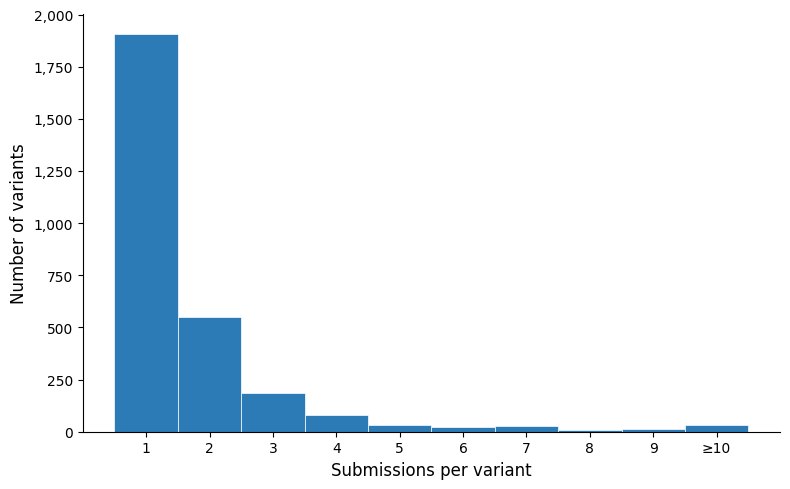

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

history = pd.read_csv("/content/ad_submission_history.csv", low_memory=False)

sub_counts = history.groupby("VariationID").size()
n = sub_counts.shape[0]
mean = sub_counts.mean()
ci_low, ci_high = stats.t.interval(0.95, df=n-1, loc=mean, scale=stats.sem(sub_counts))

print(f"Total submissions: {len(history):,}")
print(f"Unique variants: {n:,}")
print(f"Mean submissions per variant: {mean:.2f} (95% CI: {ci_low:.2f}–{ci_high:.2f})")
print(f"Median submissions per variant: {sub_counts.median():.0f}")
print(f"Max submissions for a single variant: {sub_counts.max()}")
print(f"\nDistribution of submissions per variant:")
print(sub_counts.value_counts().sort_index().head(15).to_string())
over_10 = (sub_counts > 10).sum()
print(f"Variants with >10 submissions: {over_10:,} ({over_10/n*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 5))
cap = 10
bins = np.arange(0.5, cap + 1.5, 1)
ax.hist(sub_counts.clip(upper=cap), bins=bins, color="#2c7bb6", edgecolor="white", linewidth=0.5)
ax.set_xticks(range(1, cap + 1))
ax.set_xticklabels([str(i) if i < cap else "≥10" for i in range(1, cap + 1)])
ax.set_ylabel("Number of variants", fontsize=12)
ax.set_xlabel("Submissions per variant", fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("/content/ad_submissions_per_variant.png", dpi=300)
plt.show()

In [11]:
top = sub_counts[sub_counts >= 10].sort_values(ascending=False).reset_index()
top.columns = ["VariationID", "n_submissions"]
result = ad[ad["VariationID"].isin(top["VariationID"])].merge(top, on="VariationID")
print(result[["source","VariationID","Name","Germline classification","n_submissions"]].sort_values("n_submissions", ascending=False).to_string(index=False))

source  VariationID                                         Name                                          Germline classification  n_submissions
  APOE        17864     NM_000041.4(APOE):c.388T>C (p.Cys130Arg) Conflicting classifications of pathogenicity; other; risk factor             19
 PSEN2       256184        NM_000447.3(PSEN2):c.69T>C (p.Ala23=)                                                           Benign             16
 PSEN2       256180       NM_000447.3(PSEN2):c.129C>T (p.Asn43=)                                                           Benign             16
 PSEN2        97995     NM_000447.3(PSEN2):c.185G>A (p.Arg62His)                                             Benign/Likely benign             15
 PSEN2       256181       NM_000447.3(PSEN2):c.261C>T (p.His87=)                                                           Benign             15
  MAPT        14245 NM_001377265.1(MAPT):c.2078C>T (p.Pro693Leu)                                                       Pathogenic 

In [16]:
import pandas as pd

history = pd.read_csv("/content/ad_submission_history.csv", low_memory=False)

history["DateLastEvaluated"] = pd.to_datetime(history["DateLastEvaluated"], errors="coerce")
history["year"] = history["DateLastEvaluated"].dt.year

def bucket(s):
    if pd.isna(s): return None
    s = s.strip()
    if s == "Pathogenic": return "P"
    if s == "Likely pathogenic": return "LP"
    if s == "Uncertain significance": return "VUS"
    if s == "Benign": return "B"
    if s == "Likely benign": return "LB"
    return None

history["bucket"] = history["ClinicalSignificance"].apply(bucket)

clean = history.dropna(subset=["bucket", "year"]).copy()
first_entry = clean.sort_values("year").drop_duplicates(["VariationID", "bucket"], keep="first")
print(f"Total submissions: {len(history):,}")
print(f"With both date and clean bucket: {len(clean):,}")
print(f"First-entry-per-bucket records: {len(first_entry):,}\n")

yearly = first_entry.groupby(["year","bucket"]).size().unstack(fill_value=0)
yearly = yearly.reindex(columns=["P","LP","VUS","LB","B"], fill_value=0)
cumulative = yearly.cumsum().astype(int)

print("Cumulative variants classified by year (AD, n=2,936):")
print(cumulative.to_string())

cumulative.to_csv("/content/ad_cumulative_by_year.csv")

Total submissions: 4,935
With both date and clean bucket: 4,192
First-entry-per-bucket records: 3,069

Cumulative variants classified by year (AD, n=2,936):
bucket    P   LP   VUS   LB    B
year                            
1981.0    1    0     0    0    0
1984.0    3    0     0    0    0
1987.0    4    0     0    0    0
1988.0    6    0     0    0    0
1990.0    8    0     0    0    0
1991.0   12    0     0    0    0
1992.0   15    0     0    0    1
1993.0   19    0     0    0    1
1994.0   21    0     0    0    1
1995.0   32    0     0    0    1
1996.0   34    0     0    0    1
1997.0   36    0     0    0    1
1998.0   41    0     0    0    1
1999.0   45    0     0    0    1
2000.0   56    0     0    0    1
2001.0   63    0     0    0    1
2002.0   75    0     0    0    1
2003.0   84    0     0    0    1
2004.0   92    0     0    0    1
2005.0  101    0     0    0    1
2006.0  105    0     0    0    1
2007.0  108    0     0    0    1
2008.0  111    0     0    0    1
2009.0  118    0  

/tmp/ipykernel_7082/2736526228.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  history["DateLastEvaluated"] = pd.to_datetime(history["DateLastEvaluated"], errors="coerce")


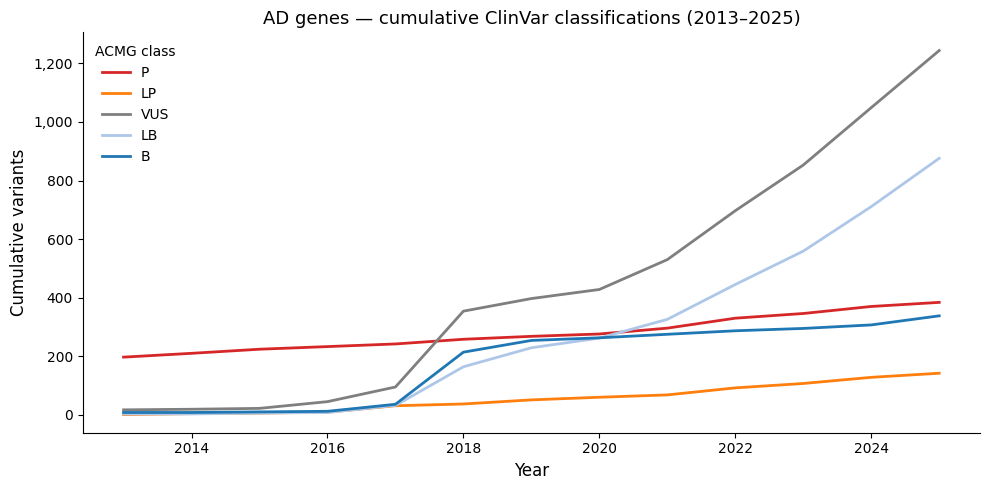

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

cumulative = pd.read_csv("/content/ad_cumulative_by_year.csv", index_col="year")
plot = cumulative.loc[(cumulative.index >= 2013) & (cumulative.index <= 2025)]

colors = {"P": "#d62728", "LP": "#ff7f0e", "VUS": "#7f7f7f", "LB": "#aec7e8", "B": "#1f77b4"}

fig, ax = plt.subplots(figsize=(10, 5))
for cls in ["P", "LP", "VUS", "LB", "B"]:
    ax.plot(plot.index, plot[cls], label=cls, color=colors[cls], linewidth=2)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Cumulative variants", fontsize=12)
ax.set_title("AD genes — cumulative ClinVar classifications (2013–2025)", fontsize=13)
ax.legend(title="ACMG class", frameon=False)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("/content/ad_cumulative_curve.png", dpi=300)
plt.show()

In [18]:
import numpy as np
from scipy import stats

cum = cumulative.copy()
cum = cum[(cum.index >= 2013) & (cum.index <= 2025)].reset_index()

x = cum["year"].values

print(f"Year range: {cum['year'].min()}–{cum['year'].max()}\n")

for b in ["P", "LP", "VUS", "LB", "B"]:
    y = cum[b].values
    if y.max() == 0:
        continue

    slope_lin, intercept_lin, r_lin, _, _ = stats.linregress(x, y)
    r2_lin = r_lin ** 2

    mask = y > 0
    if mask.sum() < 3:
        continue
    log_y = np.log(y[mask])
    slope_exp, intercept_exp, r_exp, _, _ = stats.linregress(x[mask], log_y)
    r2_exp = r_exp ** 2

    better = "exponential" if r2_exp > r2_lin else "linear"

    print(f"{b} [{better}]:")
    print(f"  Linear:      y = {slope_lin:.2f}x + ({intercept_lin:.2f})   R² = {r2_lin:.4f}   slope = +{slope_lin:.1f} variants/yr")
    print(f"  Exponential: y = e^({slope_exp:.4f}x + ({intercept_exp:.4f}))   R² = {r2_exp:.4f}   growth = +{(np.exp(slope_exp)-1)*100:.1f}%/yr   doubling = {np.log(2)/slope_exp:.3f} yrs")
    print()

Year range: 2013.0–2025.0

P [exponential]:
  Linear:      y = 15.53x + (-31081.52)   R² = 0.9705   slope = +15.5 variants/yr
  Exponential: y = e^(0.0554x + (-106.3238))   R² = 0.9898   growth = +5.7%/yr   doubling = 12.502 yrs

LP [linear]:
  Linear:      y = 12.18x + (-24526.37)   R² = 0.9608   slope = +12.2 variants/yr
  Exponential: y = e^(0.3715x + (-746.7336))   R² = 0.8809   growth = +45.0%/yr   doubling = 1.866 yrs

VUS [linear]:
  Linear:      y = 102.95x + (-207403.76)   R² = 0.9285   slope = +102.9 variants/yr
  Exponential: y = e^(0.3972x + (-796.6737))   R² = 0.9162   growth = +48.8%/yr   doubling = 1.745 yrs

LB [exponential]:
  Linear:      y = 71.36x + (-143791.30)   R² = 0.9010   slope = +71.4 variants/yr
  Exponential: y = e^(0.5313x + (-1068.3896))   R² = 0.9073   growth = +70.1%/yr   doubling = 1.305 yrs

B [linear]:
  Linear:      y = 32.79x + (-66016.90)   R² = 0.8685   slope = +32.8 variants/yr
  Exponential: y = e^(0.3738x + (-750.2891))   R² = 0.8047   growth 

In [19]:
import pandas as pd

history = pd.read_csv("/content/ad_submission_history.csv", low_memory=False)
history["DateLastEvaluated"] = pd.to_datetime(history["DateLastEvaluated"], errors="coerce")

def bucket(s):
    if pd.isna(s): return None
    s = str(s).strip()
    if s == "Pathogenic": return "P"
    if s == "Likely pathogenic": return "LP"
    if s == "Uncertain significance": return "VUS"
    if s == "Likely benign": return "LB"
    if s == "Benign": return "B"
    if "Pathogenic/Likely pathogenic" in s: return "P"
    if "Benign/Likely benign" in s: return "B"
    if "Uncertain" in s: return "VUS"
    if "Likely pathogenic" in s: return "LP"
    if "Likely benign" in s: return "LB"
    if "Pathogenic" in s: return "P"
    if "Benign" in s: return "B"
    return None

history["bucket"] = history["ClinicalSignificance"].apply(bucket)

dated = history.dropna(subset=["DateLastEvaluated", "bucket"]).copy()
dated = dated.sort_values("DateLastEvaluated")

first  = dated.drop_duplicates("VariationID", keep="first")
latest = dated.drop_duplicates("VariationID", keep="last")

originally_vus = set(first.loc[first["bucket"] == "VUS", "VariationID"])

reclassified = latest[latest["VariationID"].isin(originally_vus) & latest["bucket"].isin(["P","LP","LB","B"])].copy()
still_vus    = latest[latest["VariationID"].isin(originally_vus) & (latest["bucket"] == "VUS")].copy()

print(f"Variants with ≥1 dated, clean-bucket submission: {dated['VariationID'].nunique():,}")
print(f"Originally VUS:                                   {len(originally_vus):,}")
print(f"  → Reclassified:                                 {len(reclassified):,}  ({len(reclassified)/len(originally_vus)*100:.1f}%)")
print(f"  → Still VUS:                                    {len(still_vus):,}  ({len(still_vus)/len(originally_vus)*100:.1f}%)")
print(f"\nReclassification direction:")
print(reclassified["bucket"].value_counts().rename(index={"P":"Pathogenic","LP":"Likely pathogenic","LB":"Likely benign","B":"Benign"}).to_string())

reclassified.to_csv("/content/ad_vus_reclassified.csv", index=False)
still_vus.to_csv("/content/ad_still_vus.csv", index=False)

Variants with ≥1 dated, clean-bucket submission: 2,719
Originally VUS:                                   1,206
  → Reclassified:                                 94  (7.8%)
  → Still VUS:                                    1,112  (92.2%)

Reclassification direction:
bucket
Likely benign        69
Benign               13
Likely pathogenic     7
Pathogenic            5


/tmp/ipykernel_7082/2863722490.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  history["DateLastEvaluated"] = pd.to_datetime(history["DateLastEvaluated"], errors="coerce")


Reclassified variants with valid dates: 94
Mean time to reclassification: 5.36 yrs (95% CI: 4.65–6.07)
Median: 6.1 yrs
Range: 0.0–12.7 yrs

By direction:
         n  mean  median
bucket                  
B       13   6.7     7.7
LB      69   5.5     6.6
LP       7   2.6     0.7
P        5   3.7     4.9


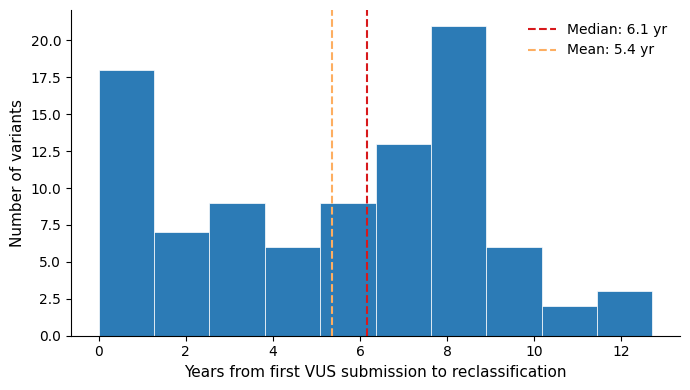

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

history = pd.read_csv("/content/ad_submission_history.csv", low_memory=False)
history["DateLastEvaluated"] = pd.to_datetime(history["DateLastEvaluated"], format="mixed", errors="coerce")

def bucket(s):
    if pd.isna(s): return None
    s = str(s).strip()
    if s == "Pathogenic": return "P"
    if s == "Likely pathogenic": return "LP"
    if s == "Uncertain significance": return "VUS"
    if s == "Likely benign": return "LB"
    if s == "Benign": return "B"
    if "Pathogenic/Likely pathogenic" in s: return "P"
    if "Benign/Likely benign" in s: return "B"
    if "Uncertain" in s: return "VUS"
    if "Likely pathogenic" in s: return "LP"
    if "Likely benign" in s: return "LB"
    if "Pathogenic" in s: return "P"
    if "Benign" in s: return "B"
    return None

history["bucket"] = history["ClinicalSignificance"].apply(bucket)
dated = history.dropna(subset=["DateLastEvaluated", "bucket"]).sort_values("DateLastEvaluated")

first_vus = (dated[dated["bucket"] == "VUS"]
             .drop_duplicates("VariationID", keep="first")
             [["VariationID", "DateLastEvaluated"]]
             .rename(columns={"DateLastEvaluated": "first_vus_date"}))

reclassified = pd.read_csv("/content/ad_vus_reclassified.csv", low_memory=False)
reclassified["DateLastEvaluated"] = pd.to_datetime(reclassified["DateLastEvaluated"], format="mixed", errors="coerce")

tta = reclassified.merge(first_vus, on="VariationID", how="left")
tta["years_to_reclassification"] = (tta["DateLastEvaluated"] - tta["first_vus_date"]).dt.days / 365.25
tta = tta[tta["years_to_reclassification"] >= 0]

n = len(tta)
mean_y = tta["years_to_reclassification"].mean()
median_y = tta["years_to_reclassification"].median()
ci_lo, ci_hi = stats.t.interval(0.95, df=n-1, loc=mean_y, scale=stats.sem(tta["years_to_reclassification"]))

print(f"Reclassified variants with valid dates: {n}")
print(f"Mean time to reclassification: {mean_y:.2f} yrs (95% CI: {ci_lo:.2f}–{ci_hi:.2f})")
print(f"Median: {median_y:.1f} yrs")
print(f"Range: {tta['years_to_reclassification'].min():.1f}–{tta['years_to_reclassification'].max():.1f} yrs")
print(f"\nBy direction:")
print(tta.groupby("bucket")["years_to_reclassification"]
        .agg(n="count", mean="mean", median="median").round(1).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(tta["years_to_reclassification"], bins=10, color="#2c7bb6", edgecolor="white", linewidth=0.5)
ax.axvline(median_y, color="#d7191c", linestyle="--", linewidth=1.5, label=f"Median: {median_y:.1f} yr")
ax.axvline(mean_y, color="#fdae61", linestyle="--", linewidth=1.5, label=f"Mean: {mean_y:.1f} yr")
ax.set_xlabel("Years from first VUS submission to reclassification", fontsize=11)
ax.set_ylabel("Number of variants", fontsize=11)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("/content/ad_time_to_reclassification.png", dpi=300)
plt.show()

tta.to_csv("/content/ad_vus_reclassified_tta.csv", index=False)

# Descriptive Statistics

In [22]:
print("Germline review status by gene:")
print(pd.crosstab(ad["source"], ad["Germline review status"], normalize="index").mul(100).round(1).to_string())

Germline review status by gene:
Germline review status  criteria provided, conflicting classifications  criteria provided, multiple submitters, no conflicts  criteria provided, single submitter  no assertion criteria provided  no classification for the single variant  no classification provided  reviewed by expert panel
source                                                                                                                                                                                                                                                                                           
APOE                                                               4.4                                                  10.5                                 69.0                            12.2                                       2.0                         1.4                       0.3
APP                                                                4.7                            

In [23]:
print(history.columns.tolist())
print(history["SubmittedPhenotypeInfo"].value_counts().head(10).to_string()
      if "SubmittedPhenotypeInfo" in history.columns else "column not found")
print(history["CollectionMethod"].value_counts().head(10).to_string()
      if "CollectionMethod" in history.columns else "column not found")

['VariationID', 'ClinicalSignificance', 'DateLastEvaluated', 'Description', 'SubmittedPhenotypeInfo', 'ReportedPhenotypeInfo', 'ReviewStatus', 'CollectionMethod', 'OriginCounts', 'Submitter', 'SCV', 'SubmittedGeneSymbol', 'ExplanationOfInterpretation', 'SomaticClinicalImpact', 'Oncogenicity', 'ContributesToAggregateClassification', 'bucket']
SubmittedPhenotypeInfo
not provided                                                       706
MedGen:CN517202                                                    387
MedGen:C0002395                                                    380
Not Provided                                                       368
MedGen:C0338451                                                    270
MedGen:C0236642;MedGen:C0338451;MedGen:C1843013;MedGen:C3151038    241
MedGen:CN169374                                                    219
MedGen:C1847200                                                    200
MedGen:CN230736                                                  

In [24]:
import pandas as pd

# Classification %
col = "Germline classification"
def classify(s):
    if pd.isna(s): return None
    s = str(s)
    if "Conflicting" in s: return "conflicting"
    if "Pathogenic/Likely" in s or s.strip() in ["Pathogenic","Likely pathogenic"]: return "p_lp"
    if "Benign/Likely" in s or s.strip() in ["Benign","Likely benign"]: return "b_lb"
    if "Uncertain" in s: return "vus"
    return "other"

ad["_cls"] = ad[col].apply(classify)
cls_pct = ad.groupby("source")["_cls"].value_counts(normalize=True).mul(100).unstack(fill_value=0)

# Review status — collapse to match JAMA table
def review(s):
    if pd.isna(s): return "no_criteria"
    if "expert panel" in s: return "expert_panel"
    if "multiple submitters" in s: return "multiple_submitters"
    if "single submitter" in s: return "single_submitter"
    return "no_criteria"

ad["_rev"] = ad["Germline review status"].apply(review)
rev_pct = ad.groupby("source")["_rev"].value_counts(normalize=True).mul(100).unstack(fill_value=0)

# Collection method — from submission history, per gene
history["VariationID"] = history["VariationID"].astype(int)
merged = history.merge(ad[["VariationID","source"]].drop_duplicates(), on="VariationID", how="left")

def coll(s):
    if pd.isna(s): return "not_provided"
    s = str(s).strip().lower()
    if s == "clinical testing": return "clinical"
    if s == "literature only": return "literature"
    if s == "research": return "research"
    return "other"

merged["_coll"] = merged["CollectionMethod"].apply(coll)
coll_pct = merged.groupby("source")["_coll"].value_counts(normalize=True).mul(100).unstack(fill_value=0)

# Variant counts
counts = ad.groupby("source").size().rename("total_variants")

# Assemble
table = pd.concat([
    counts,
    cls_pct[["p_lp","b_lb","vus","conflicting"]].rename(columns={"p_lp":"P/LP %","b_lb":"B/LB %","vus":"VUS %","conflicting":"Conflicting %"}),
    rev_pct[["expert_panel","multiple_submitters","single_submitter"]].rename(columns={"expert_panel":"Expert panel %","multiple_submitters":"Multiple submitters %","single_submitter":"Single submitter %"}),
    coll_pct[["clinical","literature","research"]].rename(columns={"clinical":"Clinical testing %","literature":"Literature only %","research":"Research %"}),
], axis=1).round(1)

print(table.to_string())
table.to_csv("/content/ad_gene_summary_table.csv")

        total_variants  P/LP %  B/LB %  VUS %  Conflicting %  Expert panel %  Multiple submitters %  Single submitter %  Clinical testing %  Literature only %  Research %
source                                                                                                                                                                    
APOE               300    11.6    37.8   40.5            4.4             0.3                   10.3                67.7                85.6                8.7         4.8
APP                715    14.2    40.2   40.3            4.7             0.0                   19.7                64.5                90.2                4.7         0.8
MAPT               672    14.7    39.9   39.3            4.8             0.0                   19.5                62.6                84.6                8.0         0.4
PSEN1              640    25.5    21.0   34.7            8.2             0.0                   15.6                57.2                78.9      